# Subgradient Descent and Proximal Gradient for the Lasso

This notebook implements and compares two approaches to solving the **Lasso** (least absolute shrinkage and selection operator) problem, which is a cornerstone of sparse estimation. The learning objectives are:

- Understand why the $\ell_1$-penalty makes the objective **nonsmooth** and why standard gradient descent does not directly apply.
- Implement **subgradient descent** and **proximal gradient descent** for the Lasso.
- Compare convergence behavior and solution quality between the two methods.

---

## Problem Formulation

The Lasso minimizes a least-squares loss plus an $\ell_1$-penalty:

$$
\min_{\mathbf{w}} \;\frac{1}{2n}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_1,
$$

where $\mathbf{X}\in\mathbb{R}^{n\times p}$ is the design matrix, $\mathbf{y}\in\mathbb{R}^n$ is the response, and $\lambda > 0$ controls the strength of regularization. The $\ell_1$-norm $\|\mathbf{w}\|_1 = \sum_j |w_j|$ promotes **sparsity**: many entries of the solution $\widehat{\mathbf{w}}$ are driven to exactly zero, performing automatic variable selection.

## Subgradient Descent

Because the $\ell_1$-norm is not differentiable at zero, we use **subgradients**. A vector $g$ is a subgradient of a convex function $f$ at $x$ if

$$
f(y) \geq f(x) + g^\top(y - x) \quad \text{for all } y.
$$

We write $g \in \partial f(x)$ for the set of all subgradients. For the Lasso objective, a subgradient at $\mathbf{w}^t$ is

$$
\mathbf{g}^t = \frac{1}{n}\mathbf{X}^\top(\mathbf{X}\mathbf{w}^t - \mathbf{y}) + \lambda\,\mathrm{sign}(\mathbf{w}^t).
$$

The update rule is $\mathbf{w}^{t+1} = \mathbf{w}^t - \alpha^t \mathbf{g}^t$, where the step size $\alpha^t$ typically must decay (e.g., $\alpha^t = c/\sqrt{t}$) to ensure convergence.

## Proximal Gradient Descent

A more efficient approach splits the objective into a **smooth** part $f(\mathbf{w}) = \frac{1}{2n}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|_2^2$ and a **nonsmooth** part $h(\mathbf{w}) = \lambda\|\mathbf{w}\|_1$. The proximal gradient update is

$$
\mathbf{w}^{t+1} = \mathrm{prox}_{\alpha h}\!\bigl(\mathbf{w}^t - \alpha\nabla f(\mathbf{w}^t)\bigr),
$$

where the **proximal operator** is defined as

$$
\mathrm{prox}_{\alpha h}(x) = \arg\min_z \Bigl\{\frac{1}{2\alpha}\|z - x\|^2 + h(z)\Bigr\}.
$$

For the $\ell_1$-norm, the proximal operator has a closed-form solution known as the **soft-thresholding** (shrinkage) operator:

$$
\mathcal{S}_\lambda(x) = \mathrm{sign}(x)\,\max(|x| - \lambda,\, 0).
$$

Proximal gradient descent converges at rate $O(1/k)$ with a constant step size $\alpha \leq 1/L$ (where $L$ is the Lipschitz constant of $\nabla f$), which is much faster than subgradient descent's $O(1/\sqrt{k})$ rate.

In [1]:
import numpy as np

def generate_sparse_linear_data(n, d, s, mu=1, sigma=1):
    """
    Generate data for a sparse linear model.

    Parameters:
    - n: number of data points
    - d: dimension of the feature vector
    - s: sparsity (number of non-zero entries in the weight vector)
    - mu: magnitude of non-zero entries in the weight vector (default: 1)
    - sigma: standard deviation of the Gaussian noise (default: 1)

    Returns:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: true weight vector of shape (d,)
    """
    # Generate the design matrix X
    X = np.random.randn(n, d)

    # Generate the sparse weight vector beta
    beta = np.zeros(d)
    # non_zero_indices = np.random.choice(d, s, replace=False)
    # beta[non_zero_indices] = mu * np.random.choice([-1, 1], s)
    beta[0:s] = mu * np.random.choice([-1, 1], s)
    # Generate the response vector y
    y = X @ beta + sigma * np.random.randn(n)

    return X, y, beta

## Subgradient Descent Implementation

The code below implements subgradient descent for the Lasso. We use PyTorch's automatic differentiation to compute subgradients of the $\ell_1$-norm. Note the decaying step size $\alpha^t = c/\sqrt{t+1}$, which is necessary for subgradient methods (unlike proximal gradient, which can use a constant step size).

In [2]:
import torch

def lasso_loss(X, y, beta, lambd):
    """
    Compute the Lasso loss function.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: weight vector of shape (d,)
    - lambd: regularization parameter

    Returns:
    - loss: Lasso loss value
    """
    n = X.shape[0]
    mse_loss = torch.mean((X @ beta - y) ** 2)
    l1_norm = torch.sum(torch.abs(beta))
    loss = 0.5 * mse_loss + lambd * l1_norm
    return loss

def subgradient_descent(X, y, beta_init=None, lambd=2, stepsize=1, max_iter=100, decay=True):
    """
    Subgradient descent algorithm for Lasso.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta_init: initial weight vector of shape (d,) (default: all-zero vector)
    - lambd: regularization parameter (default: 2)
    - stepsize: step size (default: 1)
    - max_iter: maximum number of iterations (default: 100)
    - decay: flag for using decaying step size (default: True)

    Returns:
    - beta: final weight vector of shape (d,)
    - func_values: sequence of function values
    - avg_func_values: sequence of average function values
    """
    n, d = X.shape
    if beta_init is None:
        beta = torch.zeros(d, requires_grad=True)
    else:
        beta = beta_init.clone().detach().requires_grad_(True)

    func_values = []
    avg_func_values = []
    alpha_sum = 0

    for t in range(max_iter):
        if decay:
            alpha = stepsize / torch.sqrt(torch.tensor(t + 1))
        else:
            alpha = stepsize

        loss = lasso_loss(X, y, beta, lambd)
        loss.backward()

        with torch.no_grad():
            beta -= alpha * beta.grad
            beta.grad.zero_()

        func_values.append(loss.item())

    return beta.detach(), func_values

## Proximal Gradient Descent Implementation

The code below implements proximal gradient descent. Each iteration: (1) computes the gradient of the smooth least-squares term, (2) takes a gradient step, and (3) applies the soft-thresholding operator $\mathcal{S}_{\alpha\lambda}$ to handle the $\ell_1$-penalty. Because we only differentiate the smooth part, this method can use a larger constant step size and converges faster.

In [3]:
import torch

def least_squares_loss(X, y, beta):
    """
    Compute the least squares loss function.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta: weight vector of shape (d,)

    Returns:
    - loss: least squares loss value
    """
    n = X.shape[0]
    mse_loss = torch.mean((X @ beta - y) ** 2)
    loss = 0.5 * mse_loss
    return loss

def soft_thresholding(x, threshold):
    """
    Soft thresholding operator.

    Parameters:
    - x: input tensor
    - threshold: threshold value

    Returns:
    - soft_thresholded_x: soft thresholded tensor
    """
    return torch.sign(x) * torch.max(torch.abs(x) - threshold, torch.zeros_like(x))

def proximal_gradient_descent(X, y, beta_init=None, lambd=2, stepsize=0.1, max_iter=1000):
    """
    Proximal gradient descent algorithm for Lasso.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - beta_init: initial weight vector of shape (d,) (default: all-zero vector)
    - lambd: regularization parameter (default: 0.1)
    - stepsize: step size (default: 0.1)
    - max_iter: maximum number of iterations (default: 1000)

    Returns:
    - beta: final weight vector of shape (d,)
    - func_values: sequence of function values
    """
    n, d = X.shape
    if beta_init is None:
        beta = torch.zeros(d, requires_grad=True)
    else:
        beta = beta_init.clone().detach().requires_grad_(True)

    func_values = []

    for t in range(max_iter):
        loss = least_squares_loss(X, y, beta)
        loss.backward()

        with torch.no_grad():
            beta_temp = beta.clone().detach() - stepsize * beta.grad
            beta_temp = soft_thresholding(beta_temp, stepsize * lambd)
            beta.copy_(beta_temp)

            beta.grad.zero_()

        func_value = least_squares_loss(X, y, beta) + lambd * torch.sum(torch.abs(beta))
        func_values.append(func_value.item())

    return beta.detach(), func_values

## Experiments: Comparing Subgradient and Proximal Gradient

We generate synthetic sparse linear data with $n = 500$ observations, $p = 500$ features, and $s = 5$ nonzero entries. We then run both methods and compare: (1) convergence of the objective value, (2) parameter estimation error $\|\widehat{\mathbf{w}} - \mathbf{w}^*\|_2$.

### Step-size comparison

Below we test different step sizes. A key observation is that **proximal gradient descent tolerates larger step sizes** than subgradient descent. With a constant step size, subgradient descent may oscillate and fail to converge, while proximal gradient converges steadily as long as $\alpha \leq 1/L$.

The first 20 entries of the true parameter are:
[-2. -2. -2. -2.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.]
***Subgradient Descent with Decaying Stepsizes***
The first 20 entries of the estimated parameter are:
[-1.8994719  -1.7461147  -1.8582585  -1.8595263   1.8626539   0.01628059
  0.01203393 -0.0026754   0.01580985  0.00773688 -0.0154013  -0.00300609
  0.01115534 -0.0082113  -0.00716662 -0.00491875  0.00565174  0.00778227
 -0.01350339 -0.01810598]
Subgradient Descent - Parameter Error: 0.4717
Iteration	Function Value	Average Function Value
0			9.7482


5			4.8453


10			2.2994


15			1.9990


***Subgradient Descent with Constant Stepsizes***
The first 20 entries of the estimated parameter are:
[ -10160.266   47317.23    38667.043   97753.984   33209.676   25217.396
   44927.996   81410.63    72505.24  -117142.24    84911.4     -2157.192
   12451.629  -29578.98   -66308.29   -50702.773   15981.105   48383.246
  -48317.105  -20585.947]
Subgradient Descent - Par

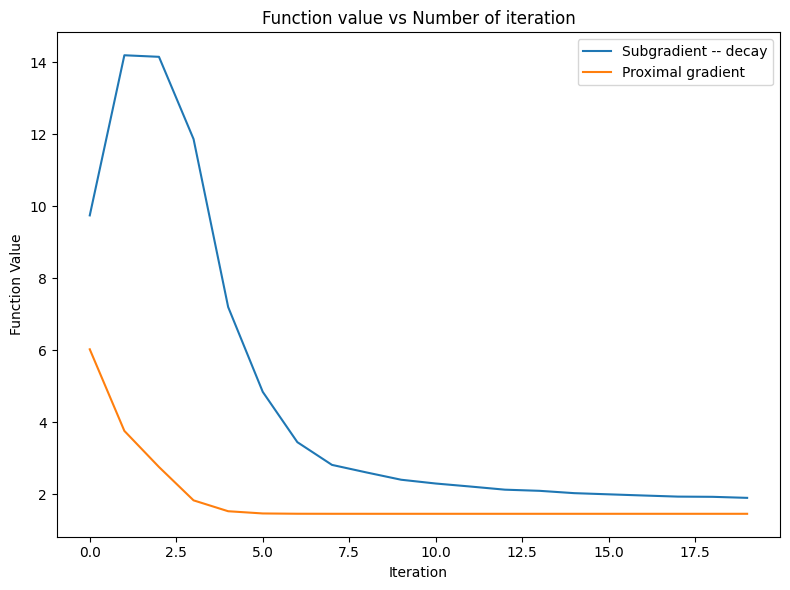

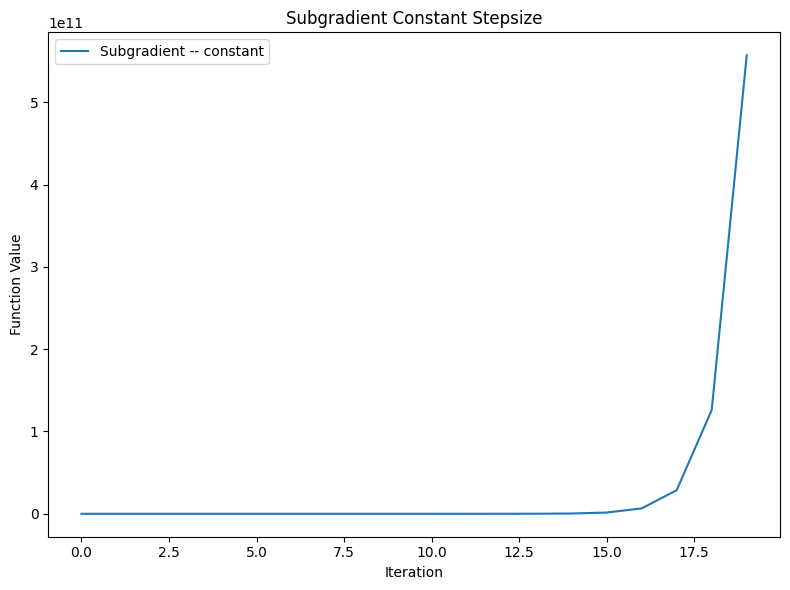

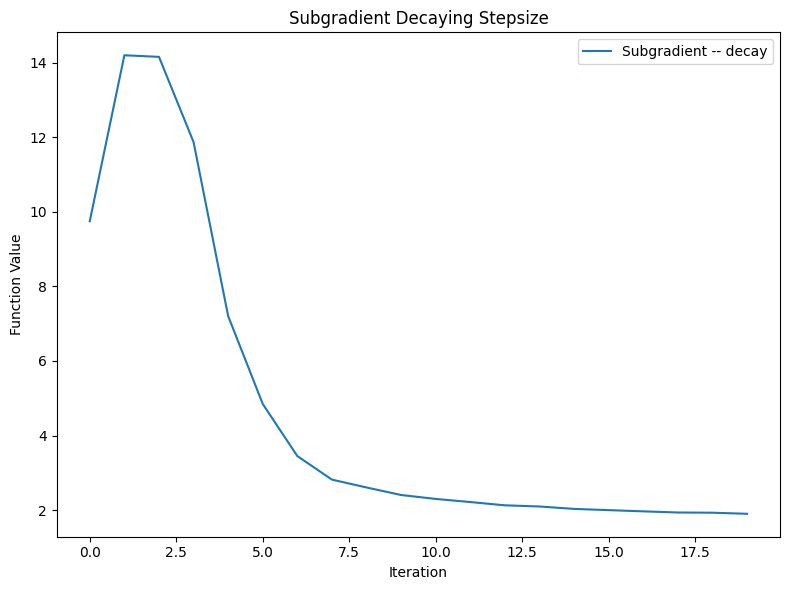

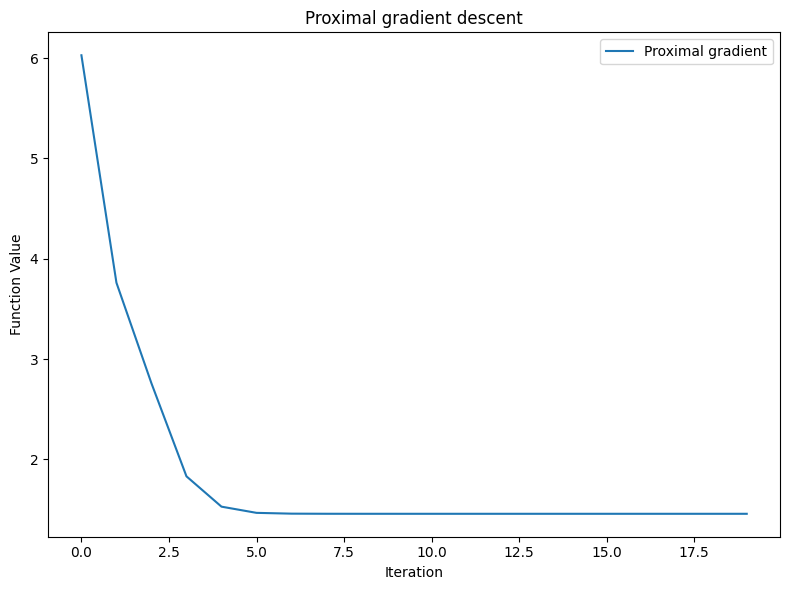

In [4]:
import matplotlib.pyplot as plt


# Set random seed for reproducibility
torch.manual_seed(0)

# Generate synthetic data
n = 500
d = 500
s = 5
mu = 2
sigma = 1
X, y, beta_true = generate_sparse_linear_data(n, d, s, mu, sigma)

# Convert data to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
beta_true = torch.tensor(beta_true, dtype=torch.float32)

print("The first 20 entries of the true parameter are:")
print(beta_true[:20].numpy())


# Set algorithm parameters
lambd = 0.1


stepsize = 0.8

max_iter = 20

# Run subgradient descent
beta_init = torch.zeros(d, dtype=torch.float32)

beta_sub_decay, fun_sub_decay = subgradient_descent(X, y, beta_init, lambd, stepsize, max_iter)

beta_sub_const, fun_sub_const = subgradient_descent(X, y, beta_init, lambd, stepsize, max_iter, decay=False)

# Run proximal gradient descent
beta_prox, fun_prox = proximal_gradient_descent(X, y, beta_init, lambd, stepsize, max_iter)


# report results

subgradient_decay_error = torch.norm(beta_sub_decay - beta_true).item()
subgradient_const_error = torch.norm(beta_sub_const - beta_true).item()
proximal_error = torch.norm(beta_prox - beta_true).item()


print("***Subgradient Descent with Decaying Stepsizes***")
print("The first 20 entries of the estimated parameter are:")
print(beta_sub_decay[:20].numpy())
print("Subgradient Descent - Parameter Error: {:.4f}".format(subgradient_decay_error))
print("Iteration\tFunction Value\tAverage Function Value")
for i in range(0, len(fun_sub_decay), 5):
    print("{}\t\t\t{:.4f}".format(i, fun_sub_decay[i]))
    print("\n")

print("***Subgradient Descent with Constant Stepsizes***")
print("The first 20 entries of the estimated parameter are:")
print(beta_sub_const[:20].numpy())
print("Subgradient Descent - Parameter Error: {:.4f}".format(subgradient_const_error))
print("Iteration\tFunction Value\tAverage Function Value")
for i in range(0, len(fun_sub_const), 5):
    print("{}\t\t\t{:.4f}".format(i, fun_sub_const[i]))
    print("\n")


print("***Proximal Gradient Descent***")
print("The first 20 entries of the estimated parameter are:")
print(beta_prox[:20].numpy())
print("Proximal Gradient Descent - Parameter Error: {:.4f}".format(proximal_error))
print("Iteration\tFunction Value")
for i in range(0, len(fun_prox), 5):
    print("{}\t\t\t{:.4f}".format(i, fun_prox[i]))


plt.figure(figsize=(8, 6))
# plt.plot(fun_sub_const, label='Subgradient -- constant')
plt.plot(fun_sub_decay, label='Subgradient -- decay')
plt.plot(fun_prox, label='Proximal gradient')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Function value vs Number of iteration')
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(fun_sub_const, label='Subgradient -- constant')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Subgradient Constant Stepsize')
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(fun_sub_decay, label='Subgradient -- decay')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Subgradient Decaying Stepsize')
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 6))
plt.plot(fun_prox, label='Proximal gradient')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Proximal gradient descent')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import cvxpy as cp
import numpy as np

def lasso_cvxpy(X, y, lambd):
    """
    Solve the Lasso problem using CVXPY.

    Parameters:
    - X: design matrix of shape (n, d)
    - y: response vector of shape (n,)
    - lambd: regularization parameter

    Returns:
    - beta_cvx: optimal weight vector of shape (d,)
    - obj_cvx: optimal objective value
    """
    n, d = X.shape

    # Convert PyTorch tensors to NumPy arrays
    X_np = X.numpy()
    y_np = y.numpy()

    # Define the optimization variables
    beta = cp.Variable(d)

    # Define the objective function
    objective = cp.Minimize(0.5 * cp.sum_squares(X_np @ beta - y_np)/n  + lambd * cp.norm(beta, 1))

    # Define the optimization problem
    problem = cp.Problem(objective)

    # Solve the optimization problem
    obj_cvx = problem.solve()

    # Retrieve the optimal weight vector
    beta_cvx = beta.value

    return beta_cvx, obj_cvx


beta_cvx, obj_cvx = lasso_cvxpy(X, y, lambd)

print("The first 20 entries of the cvx estimated parameter are:")
print(beta_cvx[:20])
cvx_error = np.linalg.norm(beta_cvx - beta_true.numpy())
print("CVXPY - Parameter Error: {:.4f}".format(cvx_error))
print("Function Value is: {:.4f}", obj_cvx)


The first 20 entries of the cvx estimated parameter are:
[-1.97488767e+00 -1.82077862e+00 -1.92658069e+00 -1.94161495e+00
  1.87150253e+00  3.31827600e-22 -1.89547190e-23 -9.39012787e-24
  4.38842349e-23 -2.84817975e-22  1.23541893e-22 -5.44554250e-22
  6.73407780e-24  2.87109653e-22 -8.86403139e-22 -4.19168459e-22
 -1.09631922e-22  6.75802994e-22  5.98979126e-22 -2.79685460e-22]
CVXPY - Parameter Error: 0.2492
Function Value is: {:.4f} 1.458265094300072


## Summary

Key takeaways from this notebook:

- The **Lasso** combines a smooth least-squares loss with a nonsmooth $\ell_1$-penalty, promoting sparse solutions that automatically select relevant features.
- **Subgradient descent** is a general-purpose method for nonsmooth optimization but converges slowly ($O(1/\sqrt{k})$) and requires a decaying step size. With a constant step size, it may oscillate around the optimum.
- **Proximal gradient descent** exploits the composite structure of the Lasso (smooth + nonsmooth) by applying the soft-thresholding operator after each gradient step. It converges at rate $O(1/k)$ with a constant step size and produces sparser, more accurate solutions in fewer iterations.
- The **soft-thresholding operator** $\mathcal{S}_\lambda(x) = \mathrm{sign}(x)\max(|x|-\lambda, 0)$ is the closed-form proximal operator for the $\ell_1$-norm. It shrinks small coefficients to exactly zero, which is why proximal gradient naturally recovers sparse solutions.
- The **CVXPY** solution serves as a ground truth to verify that our iterative methods converge to the correct optimum.